# Whole-file LM-CC results

Complexity metrics on the whole pre-patch target file, correlated with the Agentless
Claude-3.5-Sonnet `resolved` label. The all-agents resolution-rate analysis follows below.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent)) 

from src.config import PATHS
import pandas as pd

metrics_df = pd.read_parquet(PATHS.WHOLE_FILE_RESULT_DATASET)
labeled_df = pd.read_parquet(PATHS.LABELED_DATASET)

merged = metrics_df.merge(
    labeled_df[["instance_id", "resolved"]],
    on="instance_id",
    how="left",
)

clean = merged[
    merged["parsable"] 
    & merged["lm_cc_score"].notna() 
    & merged["resolved"].notna()
].copy()

print(f"Total: {len(merged)}")
print(f"Usable: {len(clean)}")
print(f"Resolve rate: {clean['resolved'].mean():.1%}")

Total: 427
Usable: 427
Resolve rate: 56.4%


## LM-CC distribution

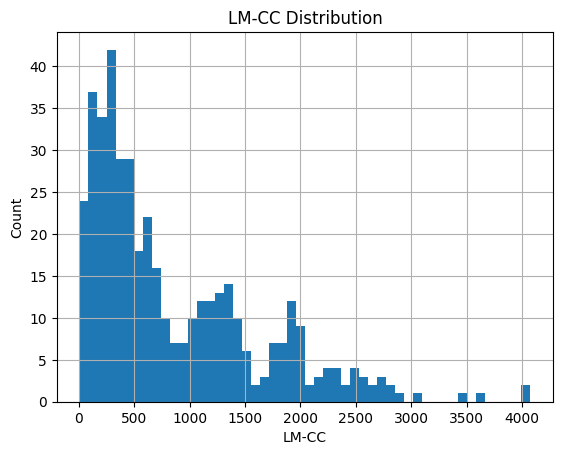

In [2]:
import matplotlib.pyplot as plt

clean["lm_cc_score"].describe()

clean["lm_cc_score"].hist(bins=50)
plt.xlabel("LM-CC")
plt.ylabel("Count")
plt.title("LM-CC Distribution")
plt.show()

## Correlation table: metrics vs. `resolved`

Zero-order and LOC-controlled (sample + subgroup) Spearman correlations.

In [3]:
from src.correlation import full_correlation_table

metrics_to_compare = [
    "cc_avg",
    "cc_max", 
    "cc_sum",
    "halstead_volume",
    "halstead_difficulty",
    "halstead_effort",
    "loc",
    "lloc",
    "nesting_max",
    "token_count",
    "function_count",
    "n_branches",
    
    "lm_cc_max_comp",      
    "lm_cc_avg_comp",      
    "lm_cc_total_comp",    
    "lm_cc_max_branch",   
    "lm_cc_avg_branch",    
    "lm_cc_total_branch",  
    
    "lm_cc_score",
]
available_metrics = [m for m in metrics_to_compare if m in clean.columns]

result_table = full_correlation_table(clean, available_metrics)
print("=== Full Correlation Table (vs. resolved) ===")
print(result_table.to_string(index=False))

=== Full Correlation Table (vs. resolved) ===
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg -0.014 (p=0.780)   -0.000 (p=0.993)                      —                      —
             cc_max -0.057 (p=0.238)   +0.006 (p=0.901)                      —                      —
             cc_sum -0.118 (p=0.015)   -0.099 (p=0.040) -0.732 (p=0.016, n=10) -0.732 (p=0.025, n=10)
    halstead_volume -0.096 (p=0.048)   -0.015 (p=0.764)                      —                      —
halstead_difficulty -0.056 (p=0.246)   +0.018 (p=0.708) -0.697 (p=0.025, n=10)                      —
    halstead_effort -0.092 (p=0.057)   -0.010 (p=0.844) -0.772 (p=0.005, n=11) -0.772 (p=0.009, n=11)
                loc -0.098 (p=0.044)                  —  -0.840 (p=0.005, n=9)                      —
               lloc -0.110 (p=0.023)   -0.093 (p=0.056)  -0.756 (p=0.018, n=9)  -0.756 (p=0.030, n=9)
        nesting_max -0.081 (p=0.093)

In [4]:
classical = ["cc_avg", "cc_max", "cc_sum", "halstead_volume", "halstead_difficulty",
             "halstead_effort", "loc", "lloc", "nesting_max", "token_count",
             "function_count", "n_branches"]
lm_cc_components = ["lm_cc_max_comp", "lm_cc_avg_comp", "lm_cc_total_comp",
                    "lm_cc_max_branch", "lm_cc_avg_branch", "lm_cc_total_branch"]
lm_cc_final = ["lm_cc_score"]

print("=" * 100)
print("Classic Metrics")
print("=" * 100)
print(result_table[result_table["metric"].isin(classical)].to_string(index=False))

print("\n" + "=" * 100)
print("LM-CC SUB-FEATURES (Paper Table 2)")
print("=" * 100)
print(result_table[result_table["metric"].isin(lm_cc_components)].to_string(index=False))

print("\n" + "=" * 100)
print("LM-CC (composite, Paper Table 2 last column)")
print("=" * 100)
print(result_table[result_table["metric"].isin(lm_cc_final)].to_string(index=False))

Classic Metrics
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg -0.014 (p=0.780)   -0.000 (p=0.993)                      —                      —
             cc_max -0.057 (p=0.238)   +0.006 (p=0.901)                      —                      —
             cc_sum -0.118 (p=0.015)   -0.099 (p=0.040) -0.732 (p=0.016, n=10) -0.732 (p=0.025, n=10)
    halstead_volume -0.096 (p=0.048)   -0.015 (p=0.764)                      —                      —
halstead_difficulty -0.056 (p=0.246)   +0.018 (p=0.708) -0.697 (p=0.025, n=10)                      —
    halstead_effort -0.092 (p=0.057)   -0.010 (p=0.844) -0.772 (p=0.005, n=11) -0.772 (p=0.009, n=11)
                loc -0.098 (p=0.044)                  —  -0.840 (p=0.005, n=9)                      —
               lloc -0.110 (p=0.023)   -0.093 (p=0.056)  -0.756 (p=0.018, n=9)  -0.756 (p=0.030, n=9)
        nesting_max -0.081 (p=0.093)   -0.031 (p=0.525)           

## Extreme cases: high / low LM-CC by resolution

In [5]:
high_resolved = clean[clean["resolved"] == 1].nlargest(5, "lm_cc_score")
print("=== High LM-CC, resolved ===")
print(high_resolved[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

high_failed = clean[clean["resolved"] == 0].nlargest(5, "lm_cc_score")
print("=== High LM-CC, not resolved ===")
print(high_failed[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

low_resolved = clean[clean["resolved"] == 1].nsmallest(5, "lm_cc_score")
print("\n=== Low LM-CC, resolved ===")
print(low_resolved[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

low_failed = clean[clean["resolved"] == 0].nsmallest(5, "lm_cc_score")
print("\n=== Low LM-CC, not resolved ===")
print(low_failed[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

=== High LM-CC, resolved ===
                 instance_id  lm_cc_score  loc  cc_sum  nesting_max
matplotlib__matplotlib-26113       4074.6 3612     755            6
matplotlib__matplotlib-24149       4031.2 3566     745            6
matplotlib__matplotlib-13989       3590.2 3400     707            6
          sympy__sympy-19954       3464.0 2378     744            7
         pydata__xarray-3677       3021.2 2796     779            9
=== High LM-CC, not resolved ===
                 instance_id  lm_cc_score  loc  cc_sum  nesting_max
          sympy__sympy-18698       2881.6 3037     900            6
          sympy__sympy-24562       2850.2 2831    1030           13
          sympy__sympy-13757       2741.2 2976     885            6
matplotlib__matplotlib-24177       2716.4 2404     680           10
matplotlib__matplotlib-26208       2696.2 2406     703            9

=== Low LM-CC, resolved ===
                 instance_id  lm_cc_score  loc  cc_sum  nesting_max
        django__django-11

## LM-CC: resolved vs. not resolved

In [6]:
import numpy as np

print("=== LM-CC: resolved vs. not resolved ===")

resolved_lmcc = clean[clean["resolved"] == 1]["lm_cc_score"]
failed_lmcc = clean[clean["resolved"] == 0]["lm_cc_score"]

print("LM-CC on resolved tasks:")
print(f"  Median: {resolved_lmcc.median():.1f}, Mean: {resolved_lmcc.mean():.1f}")
print(f"  Range: {resolved_lmcc.min():.1f} – {resolved_lmcc.max():.1f}")

print("\nLM-CC on not resolved tasks:")
print(f"  Median: {failed_lmcc.median():.1f}, Mean: {failed_lmcc.mean():.1f}")
print(f"  Range: {failed_lmcc.min():.1f} – {failed_lmcc.max():.1f}")

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(resolved_lmcc, failed_lmcc)
print(f"\nMann-Whitney-U: p={p:.3f}")


=== LM-CC: resolved vs. not resolved ===
LM-CC on resolved tasks:
  Median: 477.4, Mean: 796.8
  Range: 16.4 – 4074.6

LM-CC on not resolved tasks:
  Median: 708.2, Mean: 936.8
  Range: 5.4 – 2881.6

Mann-Whitney-U: p=0.022


## Collinearity with LOC

In [7]:
from scipy.stats import spearmanr

metrics = ["lm_cc_score", "lm_cc_total_comp", "lm_cc_total_branch",
           "cc_sum", "halstead_volume", "lloc", "nesting_max", "n_branches"]

print("=== Collinearity with LOC ===")
print(f"{'Metric':<22} {'ρ with LOC':>10}")
for m in metrics:
    rho, _ = spearmanr(clean[m], clean["loc"])
    print(f"{m:<22} {rho:>+10.3f}")

=== Collinearity with LOC ===
Metric                 ρ with LOC
lm_cc_score                +0.985
lm_cc_total_comp           +0.978
lm_cc_total_branch         +0.989
cc_sum                     +0.973
halstead_volume            +0.922
lloc                       +0.989
nesting_max                +0.575
n_branches                 +0.944


## Descriptive statistics

In [8]:
print("=== Descriptive Statistics ===")

metrics = ["lm_cc_score", "lm_cc_total_comp", "lm_cc_total_branch", "lm_cc_max_comp",
           "cc_sum", "halstead_volume", "loc", "lloc", "nesting_max", "n_branches"]

desc = clean[metrics].describe().T  # transponiert: Metriken als Zeilen
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
print(desc.round(2).to_string())

# Resolve-Rate
print(f"\nResolve rate: {clean['resolved'].mean():.1%}")
print(f"Total tasks: {len(clean)}")
print(f"Resolved: {clean['resolved'].sum()}, Not resolved: {(~clean['resolved'].astype(bool)).sum()}")

=== Descriptive Statistics ===
                    count     mean      std   min     25%      50%      75%       max
lm_cc_score         427.0   857.80   765.58   5.4  271.50   581.60  1304.50   4074.60
lm_cc_total_comp    427.0  2234.22  2036.63  11.0  682.50  1432.00  3334.50  10393.00
lm_cc_total_branch  427.0   513.70   449.88   4.0  167.00   350.00   773.50   2495.00
lm_cc_max_comp      427.0     8.71     1.82   3.0    7.00     9.00    10.00     15.00
cc_sum              427.0   228.12   200.35   1.0   71.00   147.00   373.50   1030.00
halstead_volume     427.0  3810.73  4921.54   0.0  753.32  1971.44  5882.34  37272.93
loc                 427.0   798.62   691.68   7.0  260.50   557.00  1237.00   3612.00
lloc                427.0   542.46   487.20   5.0  181.00   368.00   801.50   2568.00
nesting_max         427.0     5.07     2.45   0.0    3.00     5.00     6.00     14.00
n_branches          427.0   107.47   104.96   0.0   29.00    65.00   175.00    536.00

Resolve rate: 56.4%
To

## Scatter plots: metric vs. LOC

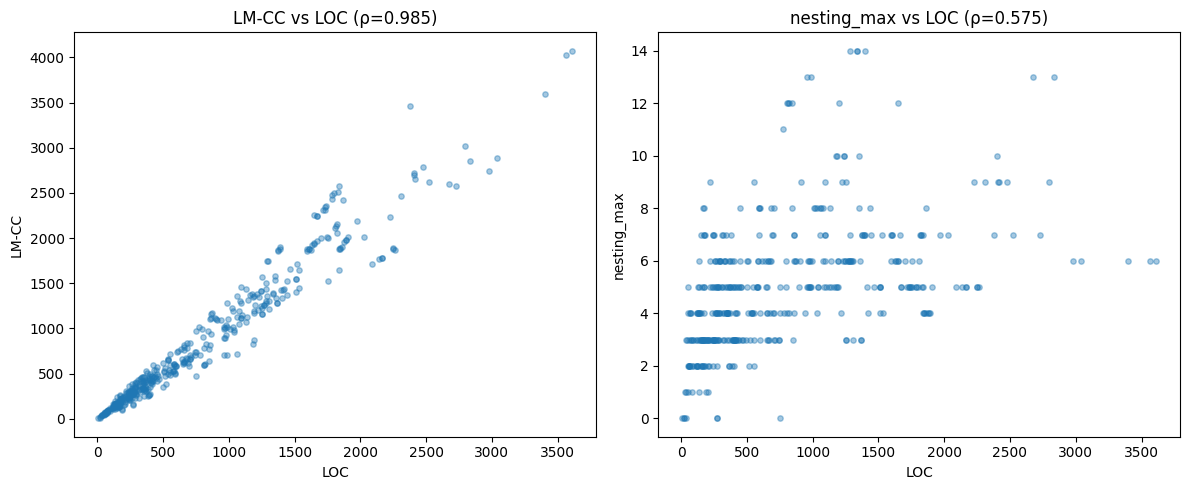

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rho1, _ = spearmanr(clean["lm_cc_score"], clean["loc"])
axes[0].scatter(clean["loc"], clean["lm_cc_score"], alpha=0.4, s=15)
axes[0].set_xlabel("LOC"); axes[0].set_ylabel("LM-CC")
axes[0].set_title(f"LM-CC vs LOC (ρ={rho1:.3f})")

rho2, _ = spearmanr(clean["nesting_max"], clean["loc"])
axes[1].scatter(clean["loc"], clean["nesting_max"], alpha=0.4, s=15)
axes[1].set_xlabel("LOC"); axes[1].set_ylabel("nesting_max")
axes[1].set_title(f"nesting_max vs LOC (ρ={rho2:.3f})")

plt.tight_layout()
plt.savefig("collinearity.png", dpi=150)
plt.show()

## All verified agents: resolution rate & per-agent LM-CC

The cells below load all verified submissions (pinned revision), derive a per-task
resolution rate (empirical difficulty), and end with Table 1: one row per agent, whether
LM-CC correlates with that agent's success. Row 1 (Agentless+Claude) matches the
single-model result above.

In [10]:
# All-of-Verified: per-task resolution rate + long per-agent predictions
all_predictions = pd.read_parquet(PATHS.ALL_PREDICTIONS)   # [instance_id, model, resolved]
difficulty = pd.read_parquet(PATHS.TASK_DIFFICULTY)        # [instance_id, n_models, n_resolved, resolution_rate]

rate = difficulty.set_index("instance_id")
clean["resolution_rate"] = clean["instance_id"].map(rate["resolution_rate"])
clean["n_resolved"] = clean["instance_id"].map(rate["n_resolved"])
n_agents = int(rate["n_models"].iloc[0])

# long table for the per-agent analysis: predictions x metrics (clean tasks only)
metric_cols = ["lm_cc_score", "loc", "cc_sum", "halstead_volume", "nesting_max"]
long = all_predictions.merge(
    clean[["instance_id", *metric_cols]], on="instance_id", how="inner"
)
print(f"agents: {all_predictions['model'].nunique()}  |  clean tasks: {clean['instance_id'].nunique()}")
print(f"long rows: {len(long):,}  (agents x clean tasks)")
clean[["resolution_rate", "n_resolved"]].describe()

agents: 134  |  clean tasks: 427
long rows: 57,218  (agents x clean tasks)


,resolution_rate,n_resolved
count,427.000000,427.000000
mean,0.561641,75.259953
std,0.300735,40.298480
min,0.000000,0.000000
25%,0.339552,45.500000
50%,0.634328,85.000000
75%,0.813433,109.000000
max,0.962687,129.000000


count    427.000000
mean       0.561641
std        0.300735
min        0.000000
25%        0.339552
50%        0.634328
75%        0.813433
max        0.962687
Name: resolution_rate, dtype: float64


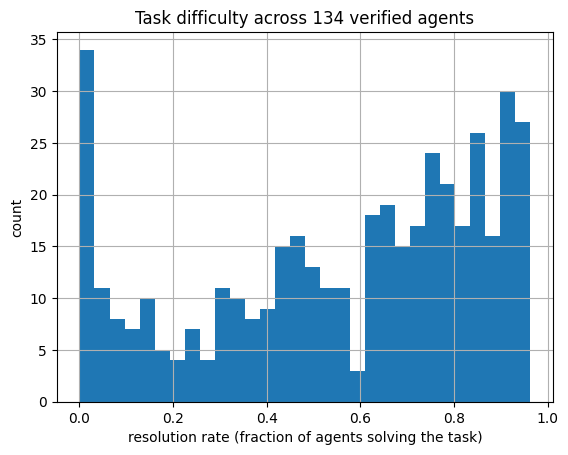

In [11]:
# Task-difficulty distribution across all verified agents
print(clean["resolution_rate"].describe())
clean["resolution_rate"].hist(bins=30)
plt.xlabel("resolution rate (fraction of agents solving the task)")
plt.ylabel("count")
plt.title(f"Task difficulty across {n_agents} verified agents")
plt.show()

In [12]:
# Complexity vs. continuous difficulty (resolution rate) - reuses full_correlation_table
rate_table = full_correlation_table(clean, available_metrics, score="resolution_rate", control="loc")
print("=== Full Correlation Table (vs. resolution_rate, all agents) ===")
print(rate_table.to_string(index=False))

=== Full Correlation Table (vs. resolution_rate, all agents) ===
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg -0.055 (p=0.255)   -0.037 (p=0.453)  -0.667 (p=0.050, n=9)                      —
             cc_max -0.106 (p=0.028)   -0.020 (p=0.685) -0.733 (p=0.016, n=10)                      —
             cc_sum -0.159 (p=0.001)   -0.082 (p=0.093)  -0.783 (p=0.013, n=9)  -0.783 (p=0.021, n=9)
    halstead_volume -0.150 (p=0.002)   -0.045 (p=0.349) -0.827 (p=0.002, n=11) -0.827 (p=0.003, n=11)
halstead_difficulty -0.121 (p=0.013)   -0.027 (p=0.581) -0.891 (p=0.001, n=10) -0.686 (p=0.041, n=10)
    halstead_effort -0.151 (p=0.002)   -0.049 (p=0.315)  -0.817 (p=0.007, n=9)  -0.817 (p=0.013, n=9)
                loc -0.144 (p=0.003)                  —  -0.750 (p=0.020, n=9)                      —
               lloc -0.165 (p=0.001)   -0.149 (p=0.002) -0.784 (p=0.007, n=10) -0.784 (p=0.012, n=10)
        nesting_m

        count        mean  median
tier                             
hard      105  916.619048   776.0
medium    121  977.647934   715.2
easy      201  754.930348   436.8

Kruskal-Wallis across tiers: p = 0.004


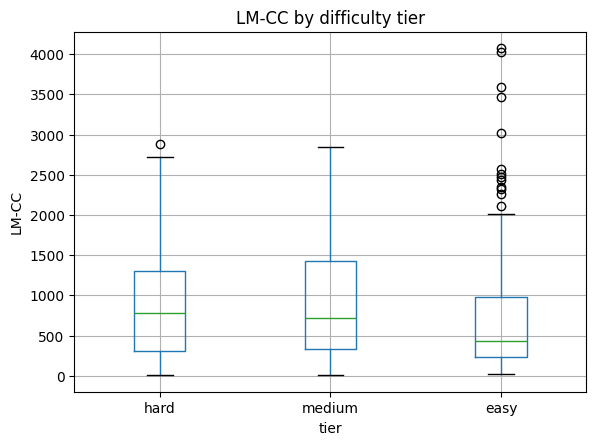

In [13]:
# LM-CC across difficulty tiers
from scipy.stats import kruskal

clean["tier"] = pd.cut(
    clean["resolution_rate"], bins=[-0.01, 0.33, 0.66, 1.01],
    labels=["hard", "medium", "easy"],
)
print(clean.groupby("tier", observed=True)["lm_cc_score"].agg(["count", "mean", "median"]))
groups = [g["lm_cc_score"].values for _, g in clean.groupby("tier", observed=True)]
print(f"\nKruskal-Wallis across tiers: p = {kruskal(*groups).pvalue:.3f}")

clean.boxplot(column="lm_cc_score", by="tier")
plt.suptitle("")
plt.title("LM-CC by difficulty tier")
plt.ylabel("LM-CC")
plt.show()

## Table 1: LM-CC across all agents

One row per agent: resolve rate plus the four correlations of LM-CC vs that agent's
`resolved`. Row 1 = Agentless+Claude, identical to the single-model result above.

In [14]:
from src.correlation import per_agent_correlation_table

table1 = per_agent_correlation_table(long, metric="lm_cc_score", score="resolved", control="loc")

def _short(name):
    # 20241202_agentless-1.5_claude-3.5-sonnet-20241022 -> agentless-1.5_claude-3.5-sonnet-20241022
    return name.split("_", 1)[1] if name[:8].isdigit() else name

show = table1.copy()
show["agent"] = show["agent"].map(_short)
show["resolve_rate"] = (show["resolve_rate"] * 100).round(1).astype(str) + " %"
for col in ["sample_zero", "sample_partial_loc", "subgroup_zero", "subgroup_partial_loc"]:
    show[col] = show[col].map(lambda v: f"{v:+.3f}")

print(f"Table 1 - LM-CC across all {len(table1)} verified agents")
print(show.to_string(index=False))

Table 1 - LM-CC across all 134 verified agents
                                                     agent resolve_rate sample_zero sample_partial_loc subgroup_zero subgroup_partial_loc
                    sonar-foundation-agent_claude-opus-4-5       84.3 %      +0.006             -0.080          +nan                 +nan
                              livesweagent_claude-opus-4-5       83.6 %      -0.070             -0.134          +nan                 +nan
                                     trae_doubao_seed_code       82.9 %      -0.041             -0.014          +nan                 +nan
                                 openhands_claude-opus-4-5       82.4 %      -0.071             -0.143          +nan                 +nan
                                                    ACoder       82.4 %      -0.053             -0.044          +nan                 +nan
                                        atlassian-rovo-dev       81.7 %      -0.038             -0.043          +nan         

In [15]:
# Top 10 agents where LM-CC best predicts failure: strongest (most negative) correlation.
# Rank by sample_zero (zero-order Spearman rho of LM-CC vs that agent's resolved).
ranking = table1.sort_values("sample_zero").head(10).copy()
ranking.insert(0, "rank", range(1, len(ranking) + 1))
ranking["agent"] = ranking["agent"].map(_short)
ranking["resolve_rate"] = (ranking["resolve_rate"] * 100).round(1).astype(str) + " %"
for col in ["sample_zero", "sample_partial_loc", "subgroup_zero", "subgroup_partial_loc"]:
    ranking[col] = ranking[col].map(lambda v: f"{v:+.3f}")

print("Top 10 agents by strongest negative LM-CC correlation (sample_zero)")
print(ranking.to_string(index=False))

Top 10 agents by strongest negative LM-CC correlation (sample_zero)
 rank                           agent resolve_rate sample_zero sample_partial_loc subgroup_zero subgroup_partial_loc
    1                 rag_claude3opus        8.2 %      -0.276             -0.048        -0.962               -0.962
    2            sweagent_claude3opus       18.3 %      -0.201             -0.083        -0.929               -0.929
    3                      nfactorial       54.8 %      -0.200             -0.147        -0.788               -0.788
    4                 composio_swekit       45.0 %      -0.199             -0.102        -0.851               -0.851
    5                     rag_claude2        4.9 %      -0.195             -0.058        -0.881               -0.881
    6    sweagent_devstral_small_2507       42.6 %      -0.194             -0.138        -0.924               -0.924
    7              appmap-navie_gpt4o       29.0 %      -0.194             -0.039        -0.862               -0.